In [1]:
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm


feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
# feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *

c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\venv310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_25.csv')


train_df = pd.concat([s19,s20,s21,s22,s23])
val_df = s24
test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
print(f"Test data shape: {test_df.shape}")
print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df

Training data shape: (123509, 912)
Training date range: 2018-10-16 to 2023-04-09
Validation data shape: (26401, 907)
Validation date range: 2023-10-24 to 2024-04-14
Test data shape: (26306, 907)
Test date range: 2024-10-22 to 2025-04-13


Unnamed: 0  Unnamed: 0.2      PLAYER_NAME  PLAYER_ID    MATCHUP  \
0               0          47.0         Alex Len     203458  ATL @ NYK   
1               1          49.0   Alex Poythress    1627816  ATL @ NYK   
2               2          48.0  DeAndre' Bembry    1627761  ATL @ NYK   
3               3          90.0     Jaylen Adams    1629121  ATL @ NYK   
4               4          87.0       Jeremy Lin     202391  ATL @ NYK   
...           ...           ...              ...        ...        ...   
25917       25917           NaN     Kobi Simmons    1628424  CHA @ CLE   
25918       25918           NaN    Mark Williams    1631109  CHA @ CLE   
25919       25919           NaN    Nick Richards    1630208  CHA @ CLE   
25920       25920           NaN   Svi Mykhailiuk    1629004  CHA @ CLE   
25921       25921           NaN     Theo Maledon    1630177  CHA @ CLE   

      TEAM_ABBREVIATION     TEAM_ID OPP_ABBREVIATION  HOME_GAME   GAME_ID  \
0                   ATL  1610612737              NYK          0  21800007   
1                   ATL  1610612737              NYK          0  21800007   
2                   ATL  1610612737              NYK          0  21800007   
3                   ATL  1610612737              NYK          0  21800007   
4                   ATL  1610612737              NYK          0  21800007   
...                 ...         ...              ...        ...       ...   
25917               CHA  1610612766              CLE          0  22201218   
25918               CHA  1610612766              CLE          0  22201218   
25919               CHA  1610612766              CLE          0  22201218   
25920               CHA  1610612766              CLE          0  22201218   
25921               CHA  1610612766              CLE          0  22201218   

        GAME_DATE WL  PTS  AST  REB  FGM  FGA  FG_PCT  FG3M  FG3A  FG3_PCT  \
0      2018-10-17  L    7    2    4    3    6   0.500     0     2    0.000   
1      2018-10-17  L    9    0    2    4    8   0.500     1     3    0.333   
2      2018-10-17  L    2    4    4    1    4   0.250     0     0      NaN   
3      2018-10-17  L    0    1    1    0    1   0.000     0     1    0.000   
4      2018-10-17  L    8    1    5    3    6   0.500     0     2    0.000   
...           ... ..  ...  ...  ...  ...  ...     ...   ...   ...      ...   
25917  2023-04-09  W    0    3    2    0    1   0.000     0     1    0.000   
25918  2023-04-09  W   22    0   10    9   10   0.900     0     0      NaN   
25919  2023-04-09  W   11    1    8    3    4   0.750     0     0      NaN   
25920  2023-04-09  W   16    6    7    6   18   0.333     2    10    0.200   
25921  2023-04-09  W   18    6    8    7   13   0.538     0     2    0.000   

       FTM  FTA  FT_PCT  OREB  DREB  STL  BLK  TOV  PLUS_MINUS  FANTASY_PTS  \
0        1    2   0.500     2     2    0    1    3         -14         14.8   
1        0    1   0.000     1     1    1    0    3         -21         11.4   
2        0    0     NaN     0     4    2    0    2         -12         16.8   
3        0    0     NaN     0     1    0    0    0           4          2.7   
4        2    2   1.000     0     5    1    0    2          -5         16.5   
...    ...  ...     ...   ...   ...  ...  ...  ...         ...          ...   
25917    0    0     NaN     1     1    0    0    0           0          6.9   
25918    4    6   0.667     1     9    1    2    2           3         41.0   
25919    5    5   1.000     2     6    1    3    3           8         31.1   
25920    2    2   1.000     4     3    2    0    3           5         36.4   
25921    4    4   1.000     1     7    1    0    3          17         36.6   

       POINT_PER_SHOT       EFG START_POSITION  COMMENT  OFF_RATING  \
0               1.017  0.500000              C      NaN        92.3   
1               1.066  0.562500            NaN      NaN        68.0   
2               0.500  0.250000            NaN      NaN        80.7   
3               0.000  

In [3]:
newFeatures = val_df.columns[val_df.columns.tolist().index('STARTING'):].tolist()
df_subset = val_df[newFeatures]

In [9]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor

def select_features_xgb_importance(X, y, top_n=150):
    xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb.fit(X, y)
    
    # Get feature importance
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': xgb.feature_importances_
    }).sort_values('importance', ascending=False)
    
    top_features = importance_df.head(top_n)['feature'].tolist()
    return X[top_features], top_features

# Select top 300 features from your newFeatures array
selected_features, top_features = select_features_xgb_importance(
    train_df[newFeatures], 
    train_df['REB'], 
    top_n=75
)
top_features = [f for f in top_features if f != 'PTS_X_TEAM_TOTAL']
# Apply the same feature selection to your other datasets
test_df_selected = test_df[top_features]
val_df_selected = val_df[top_features]

# Get the selected training data
train_df_selected = train_df[top_features]

print(f"Selected {len(top_features)} features from your newFeatures array")
print(f"Top 10 most important features:")
for i, feature in enumerate(top_features[:10]):
    print(f"{i+1}. {feature}")

Selected 75 features from your newFeatures array
Top 10 most important features:
1. REB_ROLLING_AVG_15
2. REB_ROLLING_AVG_10
3. REB_AVG_TO_DATE
4. RBC_ROLLING_AVG_15
5. RBC_ROLLING_AVG_10
6. RBC_ROLLING_AVG_5
7. RBC_WITHOUT_STAR
8. REB_PER_MIN_X_OPP_DEF_RATING
9. REB_PER_MIN_ROLLING_AVG_40
10. REB_ROLLING_AVG_40


In [12]:
xgbModel, val_metrics, used_cats = fit_train_val(
    train_df, val_df,
    features=top_features,
    target_col="REB",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False,
    tune_hyperparams=False,
    tune_iters=100
)

print("Validation metrics:", val_metrics)

test_metrics, residuals_df = evaluate_test(xgbModel, test_df, top_features, "REB", used_cats)
print("Test metrics:", test_metrics)


Validation metrics: {'RMSE': 2.3454067107250522, 'MAE': 1.781750821238923, 'R2': 0.5430397987365723, 'best_iteration': 541}
Test metrics: {'RMSE': 2.3816018252199065, 'MAE': 1.8122308463824572, 'R2': 0.528114378452301}


In [13]:
feature_importance = pd.DataFrame({
    'feature': top_features,
    'importance': xgbModel.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 vs Bottom 25 Features - Side by Side")
print("=" * 100)

# Get top 25 and bottom 25
top25 = feature_importance.head(25).reset_index(drop=True)
bottom25 = feature_importance.tail(25).reset_index(drop=True)

# Reset index for bottom 25 to start from 0
bottom25 = bottom25.reset_index(drop=True)

# Create side-by-side comparison
comparison = pd.concat([
    top25.rename(columns={'feature': 'TOP_FEATURES', 'importance': 'TOP_IMPORTANCE'}),
    bottom25.rename(columns={'feature': 'BOTTOM_FEATURES', 'importance': 'BOTTOM_IMPORTANCE'})
], axis=1)

print(comparison.to_string(index=False))

Top 25 vs Bottom 25 Features - Side by Side
                 TOP_FEATURES  TOP_IMPORTANCE                       BOTTOM_FEATURES  BOTTOM_IMPORTANCE
           REB_ROLLING_AVG_15        0.234089      RBC_EXPANDING_VOLATILITY_TO_DATE           0.002248
           REB_ROLLING_AVG_40        0.190159           PLAYER_HOME_AVG_RBC_TO_DATE           0.002242
           REB_ROLLING_AVG_10        0.094730            FANTASY_PTS_ROLLING_AVG_40           0.002221
              REB_AVG_TO_DATE        0.063977            OPP_DEF_RATING_AVG_TO_DATE           0.002182
                     STARTING        0.060619                  GAMES_PLAYED_TO_DATE           0.002178
           RBC_ROLLING_AVG_10        0.046229                             RBC_LAG_1           0.002176
           RBC_ROLLING_AVG_15        0.039194                   DIST_ROLLING_AVG_40           0.002127
             REB_WITHOUT_STAR        0.024763                 TEAM_CENTER_GT_15_PCT           0.002080
PLAYER_IS_TEAM_BEST_REBOUNDER

In [14]:
res = residuals_df.sort_values(by='residual', ascending=False, inplace=True)
top25errors = residuals_df.head(30).reset_index(drop=True)
top25errors

,actual,predicted,residual,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,TEAM_STAR_OUT,HOME_GAME,MIN
0,0,13.787257,13.787257,Domantas Sabonis,SAC @ HOU,113,103.0,1,0,0,1.27
1,0,12.159501,12.159501,Jarrett Allen,CLE vs. IND,118,126.0,1,0,1,0.68
2,2,12.654328,10.654328,Anthony Davis,LAL @ PHI,104,118.0,1,0,0,9.83
3,2,12.426846,10.426846,Nikola Jokić,DEN vs. PHX,117,90.0,1,0,1,29.75
4,2,12.414269,10.414269,Alperen Sengun,HOU vs. OKC,125,111.0,1,0,1,33.83
5,1,11.049462,10.049462,Domantas Sabonis,SAC vs. MEM,132,122.0,1,0,1,12.07
6,1,10.823857,9.823857,Jalen Duren,DET @ MIL,133,140.0,1,0,0,8.35
7,5,14.603441,9.603441,Alperen Sengun,HOU @ SAS,106,109.0,1,0,0,22.05
8,1,10.370816,9.370816,Chet Holmgren,OKC @ POR,137,114.0,1,1,0,18.38
9,2,11.231084,9.231084,Isaiah Hartenstein,OKC @ BKN,129,121.0,1,0,0,23.82


C:\Users\alexg\AppData\Local\Temp\ipykernel_25840\2114919491.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
C:\Users\alexg\AppData\Local\Temp\ipykernel_25840\2114919491.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])


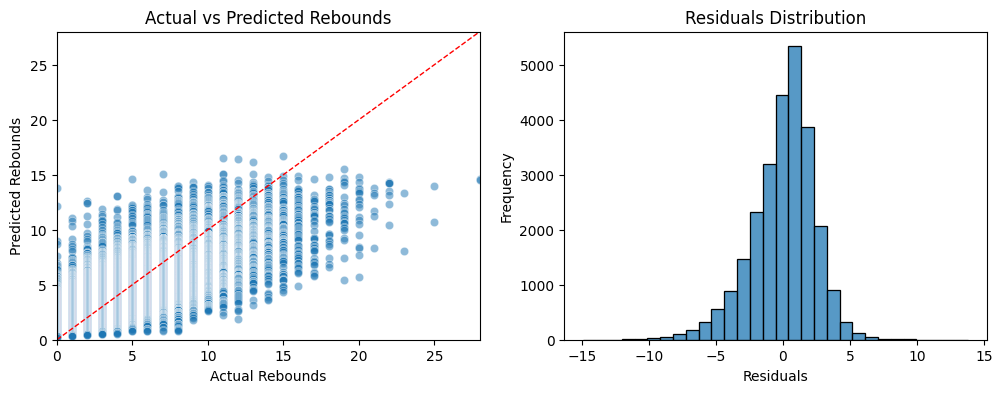

In [15]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
minVal = min(residuals_df['actual'].min(), residuals_df['predicted'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['predicted'].max())
axes[0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0].set_xlim(minVal, maxVal)
axes[0].set_ylim(minVal, maxVal)
axes[0].set_title('Actual vs Predicted Rebounds')
axes[0].set_xlabel('Actual Rebounds')
axes[0].set_ylabel('Predicted Rebounds')

sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.show()